# Variational Autoencoder for ECG Anomaly Detection

This notebook adds a probabilistic reconstruction model to the project.

Progression so far:

- **ARMA** — classical linear time-series baseline.
- **PCA** — linear reconstruction (a linear autoencoder).
- **LSTM Autoencoder** — nonlinear sequential reconstruction.
- **VAE** — probabilistic reconstruction: each beat is encoded into a Gaussian
  latent distribution and reconstructed from that latent space.

The anomaly score is still the reconstruction error, so the evaluation stays
directly comparable with the previous models.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_mit_bih_record,
    read_record_names,
    create_beat_dataset,
    split_by_record,
    evaluate_anomaly_detection,
)
from models import VAEAnomalyDetector

## Load Records

We keep the same 5-record non-paced subset used for the other models, to make the comparison easier and keep training time short.

In [2]:
N_RECORDS = 5

# Paced records are excluded via config.DROP_PACED (see read_record_names).
record_names = read_record_names(config.MIT_BIH_PATH)[:N_RECORDS]

records = []
for record_name in record_names:
    record = load_mit_bih_record(config.MIT_BIH_PATH, record_name)
    if record is not None:
        records.append(record)

print(f"Loaded {len(records)} records: {record_names}")

Loaded 5 records: ['100', '101', '103', '105', '106']


## Create Beat Dataset

Each row is one beat window of 180 samples. The label belongs to the whole beat segment.

In [3]:
dataset = create_beat_dataset(records, normalize=True)

print(dataset.shape)
display(dataset[["record", "sample", "symbol", "label", "label_name"]].head())
display(dataset["label_name"].value_counts())
display(dataset["symbol"].value_counts().head(10))

(10818, 7)


,record,sample,symbol,label,label_name
0,100,370,N,0,normal
1,100,662,N,0,normal
2,100,946,N,0,normal
3,100,1231,N,0,normal
4,100,1515,N,0,normal


label_name
normal     10211
anomaly      607
Name: count, dtype: int64

symbol
N    10211
V      562
A       38
Q        7
Name: count, dtype: int64

In [4]:
X = np.stack(dataset["signal"].values).astype("float32")
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10818, 180)
y shape: (10818,)


## Train/Test Split by Record

The split is performed by record to reduce leakage between train and test beats.

In [5]:
split = split_by_record(X, y, metadata)

print("Train records:", split["train_records"])
print("Test records:", split["test_records"])
print("Train shape:", split["X_train"].shape)
print("Test shape:", split["X_test"].shape)

print("Train labels:")
display(pd.Series(split["y_train"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

print("Test labels:")
display(pd.Series(split["y_test"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

Train records: ['100', '101', '103', '105']
Test records: ['106']
Train shape: (8791, 180)
Test shape: (2027, 180)
Train labels:


normal     8704
anomaly      87
Name: count, dtype: int64

Test labels:


normal     1507
anomaly     520
Name: count, dtype: int64

## Fit the VAE

The VAE is trained only on normal training beats (semi-supervised setup).
Training maximizes the evidence lower bound (ELBO): a reconstruction term plus a
KL term that regularizes the latent space toward a standard normal. The KL term
is used only during training; the anomaly score is the reconstruction error
computed from the latent mean (no sampling), which keeps the score deterministic
and comparable with PCA and the LSTM autoencoder.

In [6]:
MAX_TRAIN_NORMAL = 1000
MAX_TEST_PER_CLASS = 150
rng = np.random.default_rng(config.RANDOM_SEED)

X_train_normal = split["X_train"][split["y_train"] == 0]
rng.shuffle(X_train_normal)
X_train_normal = X_train_normal[:MAX_TRAIN_NORMAL]

test_indices = []
for label in [0, 1]:
    label_indices = np.where(split["y_test"] == label)[0]
    rng.shuffle(label_indices)
    test_indices.extend(label_indices[:MAX_TEST_PER_CLASS])

test_indices = np.array(test_indices)
rng.shuffle(test_indices)

X_test_eval = split["X_test"][test_indices]
y_test_eval = split["y_test"][test_indices]

print("Normal training beats used:", len(X_train_normal))
print("Test beats used:", len(X_test_eval))
display(pd.Series(y_test_eval).value_counts().rename(index={0: "normal", 1: "anomaly"}))
print("PyTorch device:", "cuda" if torch.cuda.is_available() else "cpu")

Normal training beats used: 1000
Test beats used: 300


anomaly    150
normal     150
Name: count, dtype: int64

PyTorch device: cuda


In [7]:
detector = VAEAnomalyDetector(
    input_dim=config.BEAT_LEN,
    hidden_size=64,
    latent_dim=8,
    beta=1.0,
    threshold_percentile=95,
    learning_rate=1e-3,
    batch_size=64,
    epochs=30,
    random_state=config.RANDOM_SEED,
)

detector.fit(X_train_normal)

print("Threshold:", detector.threshold)
print("Final training loss (ELBO):", detector.history[-1])

Threshold: 0.04329847935587167
Final training loss (ELBO): 1.6279470585286617


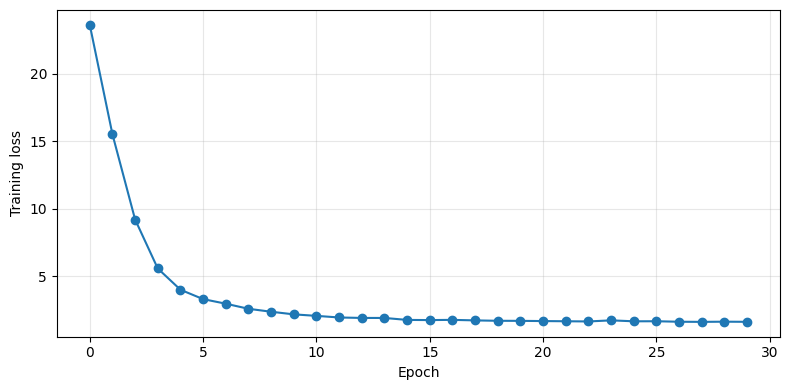

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(detector.history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Reconstruction Examples

A reconstruction model should rebuild normal beats well and struggle on
anomalous ones. We reconstruct a few beats from the latent mean (no sampling)
and overlay them on the originals.

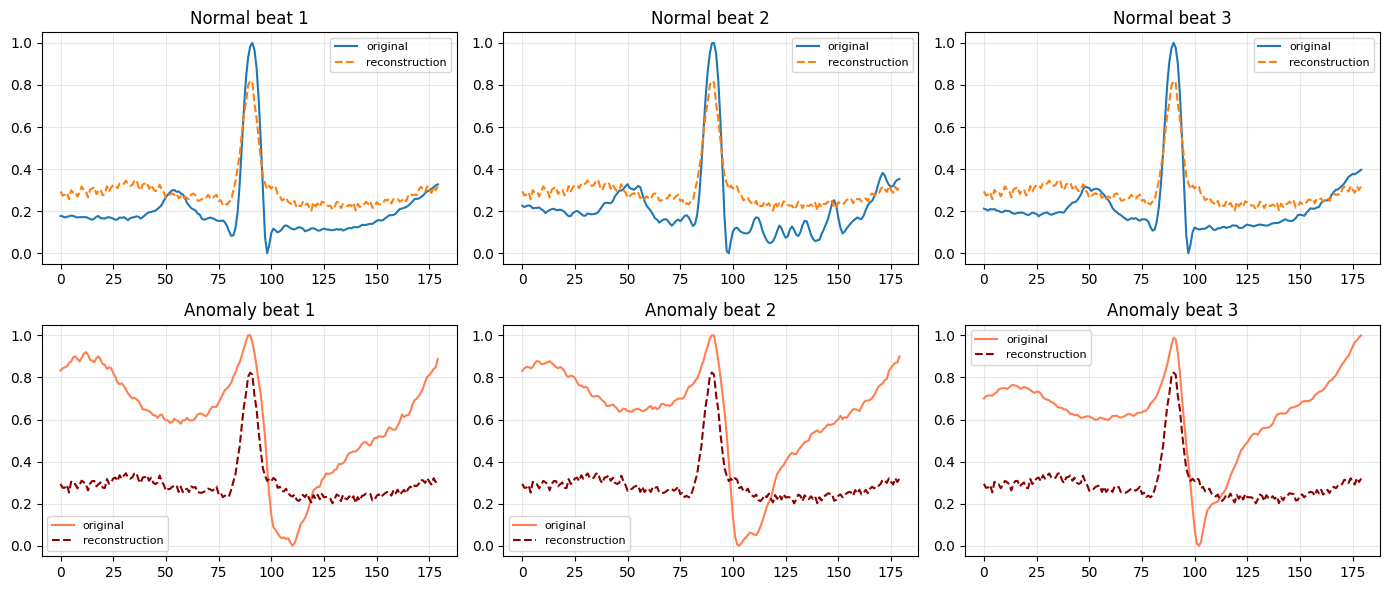

In [9]:
def reconstruct_beats(detector, beats):
    """Reconstruct beats from the VAE latent mean (no sampling)."""
    x = torch.tensor(np.asarray(beats), dtype=torch.float32).to(detector.device)
    detector.model.eval()
    with torch.no_grad():
        z_mean, _ = detector.model.encode(x)
        recon = detector.model.decode(z_mean)
    return recon.cpu().numpy()

normal_examples = X_test_eval[y_test_eval == 0][:3]
anomaly_examples = X_test_eval[y_test_eval == 1][:3]

normal_recon = reconstruct_beats(detector, normal_examples)
anomaly_recon = reconstruct_beats(detector, anomaly_examples)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i in range(3):
    axes[0, i].plot(normal_examples[i], label="original", lw=1.5)
    axes[0, i].plot(normal_recon[i], label="reconstruction", lw=1.5, linestyle="--")
    axes[0, i].set_title(f"Normal beat {i + 1}")
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].legend(fontsize=8)

for i in range(3):
    axes[1, i].plot(anomaly_examples[i], label="original", lw=1.5, color="coral")
    axes[1, i].plot(anomaly_recon[i], label="reconstruction", lw=1.5,
                    linestyle="--", color="darkred")
    axes[1, i].set_title(f"Anomaly beat {i + 1}")
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Evaluate

In [10]:
scores = detector.anomaly_score(X_test_eval)
y_pred = detector.predict(X_test_eval)

results = evaluate_anomaly_detection(y_test_eval, y_pred, scores)
results

{'confusion_matrix': [[150, 0], [41, 109]],
 'precision': 1.0,
 'recall': 0.7266666666666667,
 'f1': 0.8416988416988417,
 'roc_auc': 0.9380888888888889,
 'pr_auc': 0.9507477066386331}

### Metric Interpretation

The metrics above are computed on the same balanced subset used for the other
models, so they can be read alongside ARMA, PCA, and the LSTM autoencoder.

As for the previous reconstruction models, the ROC-AUC and PR-AUC describe how
well the reconstruction error *ranks* anomalies, independently of any threshold.
Precision and recall describe the binary decision at the default 95th-percentile
operating point and must be read together: high recall with low precision means
many anomalies are caught at the cost of false positives, while the opposite
means reliable but incomplete detection. This is a small-subset pipeline check,
not the final performance.

## Threshold Sensitivity

As with the other models, we inspect several percentiles instead of assuming the default 95th percentile is always appropriate.

In [11]:
threshold_results = []
train_scores = detector.anomaly_score(X_train_normal)

for percentile in [95, 97, 98, 99, 99.5, 99.9]:
    threshold = np.percentile(train_scores, percentile)
    y_pred_threshold = (scores > threshold).astype(int)
    metrics = evaluate_anomaly_detection(y_test_eval, y_pred_threshold, scores)

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,percentile,threshold,precision,recall,f1,roc_auc,pr_auc
0,95.0,0.043298,1.0,0.726667,0.841699,0.938089,0.950748
1,97.0,0.045379,1.0,0.706667,0.828125,0.938089,0.950748
2,98.0,0.048875,1.0,0.686667,0.814229,0.938089,0.950748
3,99.0,0.096644,1.0,0.366667,0.536585,0.938089,0.950748
4,99.5,0.142515,1.0,0.113333,0.203593,0.938089,0.950748
5,99.9,0.197392,1.0,0.020000,0.039216,0.938089,0.950748


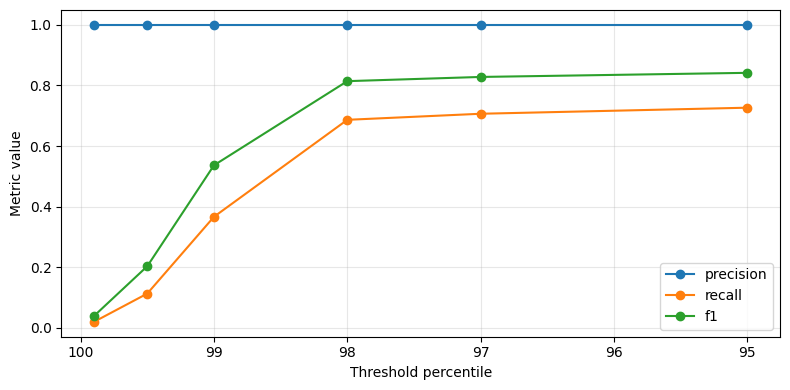

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="f1")
plt.gca().invert_xaxis()
plt.xlabel("Threshold percentile")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold Discussion

The threshold converts the reconstruction score into a binary decision. Moving
the percentile trades false positives against false negatives: lower percentiles
flag more beats (higher recall, lower precision), higher percentiles are more
conservative. The right operating point depends on the relative cost of a missed
anomaly versus a false alarm, which in a medical screening context is a decision
parameter rather than a fixed technical detail.

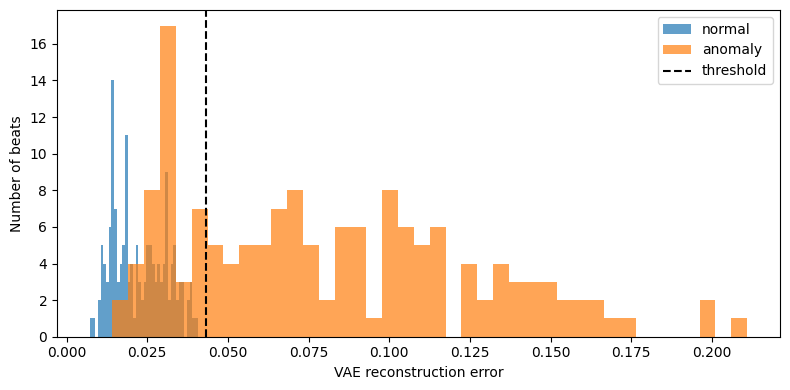

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(scores[y_test_eval == 0], bins=40, alpha=0.7, label="normal")
plt.hist(scores[y_test_eval == 1], bins=40, alpha=0.7, label="anomaly")
plt.axvline(detector.threshold, color="black", linestyle="--", label="threshold")
plt.xlabel("VAE reconstruction error")
plt.ylabel("Number of beats")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation Notes

- The VAE is the first probabilistic reconstruction model in the project.
- The encoder maps a beat to a Gaussian latent distribution; the decoder
  reconstructs the beat from that latent space.
- Training optimizes the ELBO (reconstruction + KL), but the anomaly score is
  the reconstruction error from the latent mean, keeping it comparable with PCA
  and the LSTM autoencoder.
- The `beta` parameter controls the weight of the KL term (beta-VAE): higher
  values give a more regularized latent space at the cost of reconstruction
  quality.
- Whether the probabilistic latent space helps over a plain autoencoder is an
  empirical question, to be answered under the same evaluation protocol once all
  models are trained on the full dataset.